### 1) Charger le graphe Facebook SNAP

In [ ]:
import urllib.request, gzip, shutil
import networkx as nx

url = "https://snap.stanford.edu/data/facebook_combined.txt.gz"
local_gz = "facebook_combined.txt.gz"
local_txt = "facebook_combined.txt"

# Download
urllib.request.urlretrieve(url, local_gz)

# Unzip
with gzip.open(local_gz, 'rb') as f_in:
    with open(local_txt, 'wb') as f_out:
        shutil.copyfileobj(f_in, f_out)

# Load into NetworkX
G = nx.read_edgelist(local_txt, nodetype=int)
G = nx.Graph(G)
print(G)

Graph with 4039 nodes and 88234 edges


### 2) Nombre de nœuds et d’arêtes

In [2]:
print("Nœuds:", G.number_of_nodes())
print("Arêtes:", G.number_of_edges())

Nœuds: 4039
Arêtes: 88234


### 3) Visualisation avec matplotlib

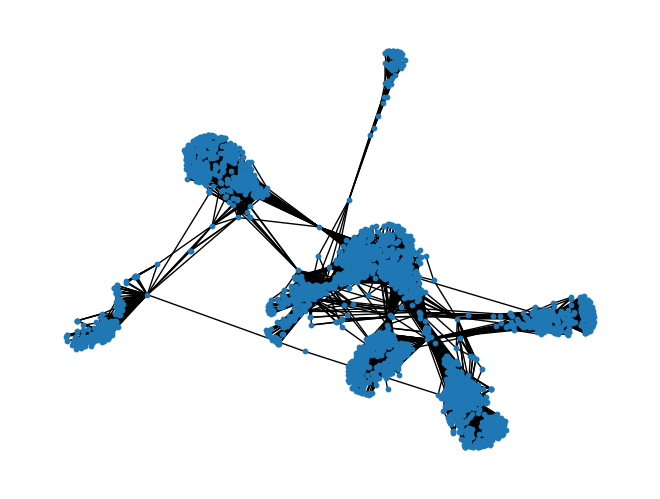

In [3]:
import matplotlib.pyplot as plt

pos = nx.spring_layout(G, seed=0)
nx.draw(G, pos, node_size=10, with_labels=False)
plt.show()

### 4) Degré de chaque nœud

In [4]:
degrees = dict(G.degree())
list(degrees.items())[:10]

[(0, 347),
 (1, 17),
 (2, 10),
 (3, 17),
 (4, 10),
 (5, 13),
 (6, 6),
 (7, 20),
 (8, 8),
 (9, 57)]

### 5) Distribution des degrés

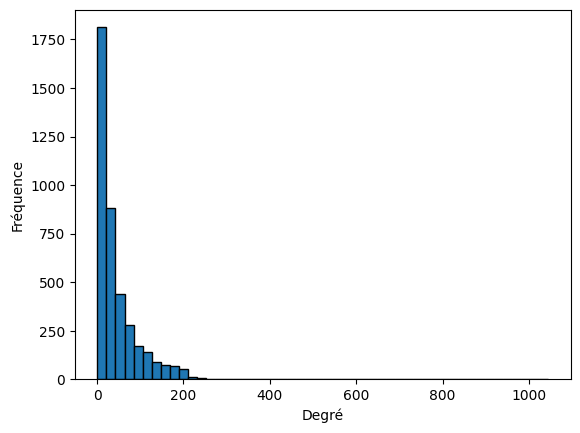

In [5]:
plt.hist(list(degrees.values()), bins=50, edgecolor="black")
plt.xlabel("Degré")
plt.ylabel("Fréquence")
plt.show()

### 6) Visualisation interactive avec ipycytoscape

In [ ]:
from ipycytoscape import CytoscapeWidget

cyto = CytoscapeWidget()

# you can add directly from a NetworkX graph
# for big graphs, better to sub-sample
H = G.subgraph(list(G.nodes())[:500]).copy()

cyto.graph.add_graph_from_networkx(H)

cyto